# Klasyczna Wizja Komputerowa: Filtry i Detekcja Krawędzi

Celem tego notatnika jest praktyczne omówienie podstawowych operacji na obrazach z wykorzystaniem biblioteki **OpenCV**. Jak wiemy z teorii, analiza obrazu często opiera się na wyszukiwaniu konkretnych cech (ang. features). Cechy te to najczęściej krawędzie (nagłe zmiany intensywności), rogi (przecięcia krawędzi), linie oraz skupiska.

## Przegląd Bibliotek Programistycznych do Wizji Komputerowej

Zanim przejdziemy do implementacji algorytmów, warto zastanowić się nad wyborem odpowiedniego narzędzia. W ekosystemie języka Python istnieje kilka popularnych bibliotek realizujących zadania z zakresu klasycznej wizji komputerowej (filtrowanie, detekcja krawędzi, sploty). Oto ich krótkie zestawienie:

| Biblioteka | Główne zastosowanie i cechy | Dostępność omawianych algorytmów |
| :--- | :--- | :--- |
| **OpenCV (`cv2`)** | **Standard rynkowy.** Niezwykle szybka biblioteka napisana pierwotnie w C/C++. Idealna do analizy wideo i obrazów w czasie rzeczywistym. | Posiada gotowe, zoptymalizowane funkcje dla Sobela, Canny'ego, filtrów rozmywających i morfologicznych. |
| **Scikit-Image (`skimage`)** | Biblioteka wywodząca się ze środowiska naukowego. Posiada bardzo czytelny, "pythonowy" interfejs i świetnie integruje się z ekosystemem NumPy/SciPy. | Posiada bogaty zestaw filtrów, często łatwiejszych w konfigurowaniu niż w OpenCV, idealna do badań (np. analiza medyczna). |
| **SciPy (`scipy.ndimage`)** | Służy do ogólnych obliczeń naukowych. Moduł ndimage pozwala na bardzo precyzyjne, niskopoziomowe operacje na wielowymiarowych tablicach. | Świetna do ręcznego definiowania masek i wykonywania n-wymiarowych splotów (konwolucji), ale brakuje jej wysokopoziomowych gotowców (jak cały algorytm Canny'ego). |
| **Pillow (`PIL`)** | Podstawowa biblioteka do otwierania, zapisywania i prostej manipulacji obrazami (zmiana rozmiaru, formatu, podstawowe filtry artystyczne). | Zbyt prosta do zaawansowanej matematycznej analizy obrazu. Brak dedykowanych detektorów krawędzi opartych na pochodnych kierunkowych. |

### Ocena i Wybór (Werdykt)

Naszym zdaniem **najlepszą biblioteką do realizacji tego ćwiczenia jest OpenCV**. 

**Dlaczego?**
1. **Gotowe implementacje:** Posiada wbudowane, silnie zoptymalizowane funkcje takie jak `cv2.Sobel()`, `cv2.GaussianBlur()` czy kompletny wieloetapowy algorytm `cv2.Canny()`.
2. **Standard przemysłowy:** Znajomość OpenCV to absolutna podstawa dla każdego inżyniera Computer Vision.
3. **Wydajność:** Dzięki implementacji w C++, operacje na macierzach obrazu (nawet o wysokiej rozdzielczości) wykonywane są błyskawicznie.

W poniższym kodzie wykorzystamy właśnie OpenCV do obliczeń oraz bibliotekę matplotlib do wygodnej wizualizacji wyników bezpośrednio w notatniku. W przypadku algorytmów niedostępnych domyślnie w OpenCV (np. filtr Prewitta), posłużymy się ręczną konwolucją za pomocą funkcji `cv2.filter2D()`.


## 1. Wczytanie obrazu testowego
Na początek ładujemy z dysku nasze zdjęcie testowe i konwertujemy je do skali szarości, co jest standardem przed wykrywaniem krawędzi.

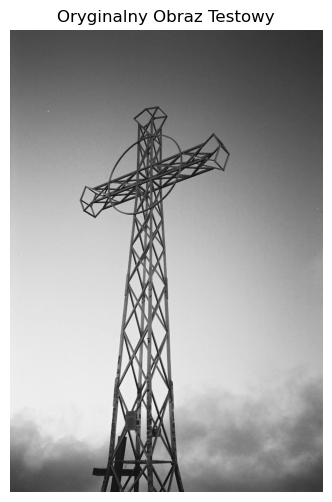

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Wczytanie obrazu w skali szarości (podmień 'zdjecie.jpg' na swój plik)
base_img = cv2.imread('zdjecie.jpg', cv2.IMREAD_GRAYSCALE)

if base_img is None:
    print("Błąd: Nie znaleziono pliku obrazu!")
else:
    plt.figure(figsize=(6, 6))
    plt.imshow(base_img, cmap='gray')
    plt.title('Oryginalny Obraz Testowy')
    plt.axis('off')
    plt.show()

## 2. Redukcja Szumów: Filtry Liniowe i Nieliniowe

Cechy wykrywa się poprzez filtrowanie obrazu. Dzielimy je na:
* **Filtry liniowe:** Wykorzystują operację splotu (konwolucji) maski z obrazem. Przykładem jest uśrednianie (Average) lub rozmycie Gaussa (Gaussian Blur).
* **Filtry nieliniowe:** Nie używają konwolucji, lecz bazują na nieliniowej funkcji (np. sortowaniu pikseli) w obrębie maski. Idealnym przykładem jest filtr medianowy, świetny na szum "pieprz i sól".

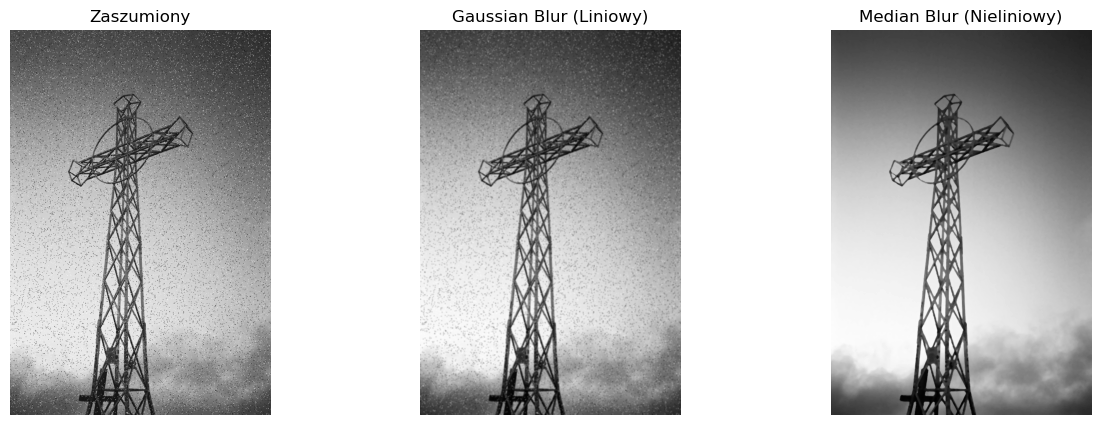

In [3]:
if base_img is not None:
    # Dodawanie sztucznego szumu Salt & Pepper
    noisy_img = base_img.copy()
    noise_amount = 0.05
    num_salt = np.ceil(noise_amount * base_img.size * 0.5)
    num_pepper = np.ceil(noise_amount * base_img.size * 0.5)

    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in base_img.shape]
    noisy_img[tuple(coords)] = 255
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in base_img.shape]
    noisy_img[tuple(coords)] = 0

    # Filtry
    blur_gauss = cv2.GaussianBlur(noisy_img, (5, 5), 0) # Liniowy
    blur_median = cv2.medianBlur(noisy_img, 5)          # Nieliniowy

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(noisy_img, cmap='gray'); ax[0].set_title('Zaszumiony')
    ax[1].imshow(blur_gauss, cmap='gray'); ax[1].set_title('Gaussian Blur (Liniowy)')
    ax[2].imshow(blur_median, cmap='gray'); ax[2].set_title('Median Blur (Nieliniowy)')
    for a in ax: a.axis('off')
    plt.show()

## 3. Detekcja Krawędzi: Pochodne pierwszego rzędu

Krawędź to nagła zmiana intensywności w obrazie. Aby ją znaleźć, liczymy pierwszą pochodną (gradient). Poniżej porównujemy trzy historyczne operatory:
1. **Operator Robertsa (Krzyżowy):** Jeden z pierwszych detektorów. Wykorzystuje małe maski $2\times2$. Jest bardzo wrażliwy na szum ze względu na swoją lokalność.
2. **Operator Prewitta:** Używa masek $3\times3$ z jednakowymi wagami (1, 1, 1). Jest prostszy obliczeniowo, ale dość wrażliwy na szum.
3. **Operator Sobela:** Ulepszona wersja używająca masek $3\times3$ z wagami (1, 2, 1), co wprowadza redukcję szumu przez uśrednianie. Jest o wiele mniej wrażliwy na szum niż operator Robertsa.

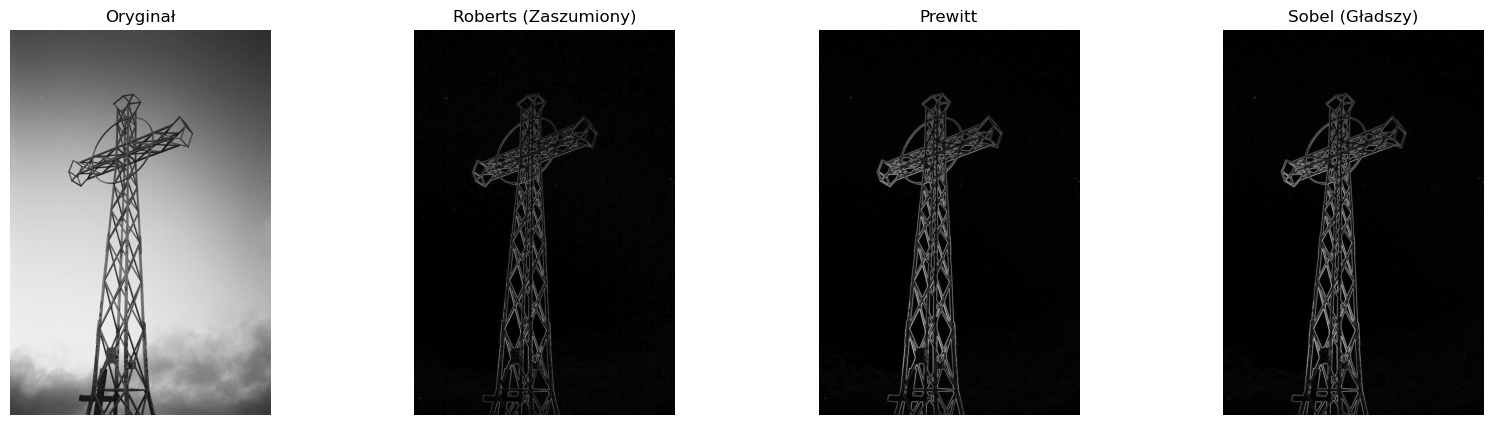

In [4]:
if base_img is not None:
    # 1. Roberts (maski 2x2 ukośne)
    roberts_x = np.array([[0, 1], [-1, 0]], dtype=np.float32)
    roberts_y = np.array([[1, 0], [0, -1]], dtype=np.float32)
    img_roberts_x = cv2.filter2D(base_img, cv2.CV_64F, roberts_x)
    img_roberts_y = cv2.filter2D(base_img, cv2.CV_64F, roberts_y)
    roberts_combined = cv2.magnitude(img_roberts_x, img_roberts_y)

    # 2. Prewitt (maski 3x3 bez uśredniania)
    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    img_prewitt_x = cv2.filter2D(base_img, cv2.CV_64F, prewitt_x)
    img_prewitt_y = cv2.filter2D(base_img, cv2.CV_64F, prewitt_y)
    prewitt_combined = cv2.magnitude(img_prewitt_x, img_prewitt_y)

    # 3. Sobel (wbudowany, z wagami 1, 2, 1)
    sobel_x = cv2.Sobel(base_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(base_img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(base_img, cmap='gray'); ax[0].set_title('Oryginał')
    ax[1].imshow(roberts_combined, cmap='gray'); ax[1].set_title('Roberts (Zaszumiony)')
    ax[2].imshow(prewitt_combined, cmap='gray'); ax[2].set_title('Prewitt')
    ax[3].imshow(sobel_combined, cmap='gray'); ax[3].set_title('Sobel (Gładszy)')
    for a in ax: a.axis('off')
    plt.show()

## 4. Druga pochodna: Laplasjan i LoG

Najbardziej precyzyjną metodą lokalizacji krawędzi jest znalezienie punktu przegięcia, gdzie druga pochodna równa się zero. Służy do tego Laplasjan. 
Niestety, czysty Laplasjan ma ogromną wrażliwość na szum. Aby temu zaradzić, najpierw wygładzamy obraz filtrem Gaussa, tworząc potężny detektor **LoG (Laplacian of Gaussian)**.

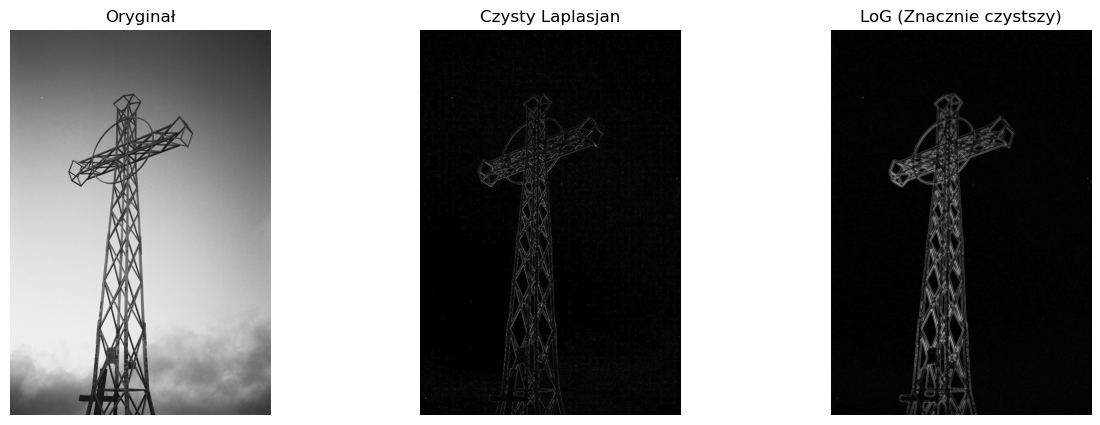

In [5]:
if base_img is not None:
    # 1. Czysty Laplasjan (bardzo chwyta szum)
    laplacian_raw = cv2.Laplacian(base_img, cv2.CV_64F)

    # 2. LoG (Laplacian of Gaussian)
    img_blurred = cv2.GaussianBlur(base_img, (5, 5), 0)
    log = cv2.Laplacian(img_blurred, cv2.CV_64F)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(base_img, cmap='gray'); ax[0].set_title('Oryginał')
    ax[1].imshow(np.abs(laplacian_raw), cmap='gray'); ax[1].set_title('Czysty Laplasjan')
    ax[2].imshow(np.abs(log), cmap='gray'); ax[2].set_title('LoG (Znacznie czystszy)')
    for a in ax: a.axis('off')
    plt.show()

## 5. Algorytm Canny'ego (Złoty Standard)

Zaproponowany w 1986 roku, jest to wieloetapowy, optymalny detektor krawędzi. Składa się z następujących etapów:
1. **Filtracja gaussowska:** Wygładzenie obrazu (parametr $\sigma$) w celu redukcji szumu.
2. **Obliczanie gradientu:** Moduł i kierunek gradientu (często Sobelem).
3. **Non-Maximum Suppression:** Usuwanie niemaksymalnych pikseli. Pozostawia tylko precyzyjne linie o grubości dokładnie 1 piksela.
4. **Progowanie z histerezą:** Wykorzystuje dwa progi ($T_1$ i $T_2$). Krawędzie powyżej $T_2$ są pewne, te poniżej $T_1$ są odrzucane, a te pomiędzy są łączone z pewnymi w ciągłe kontury.

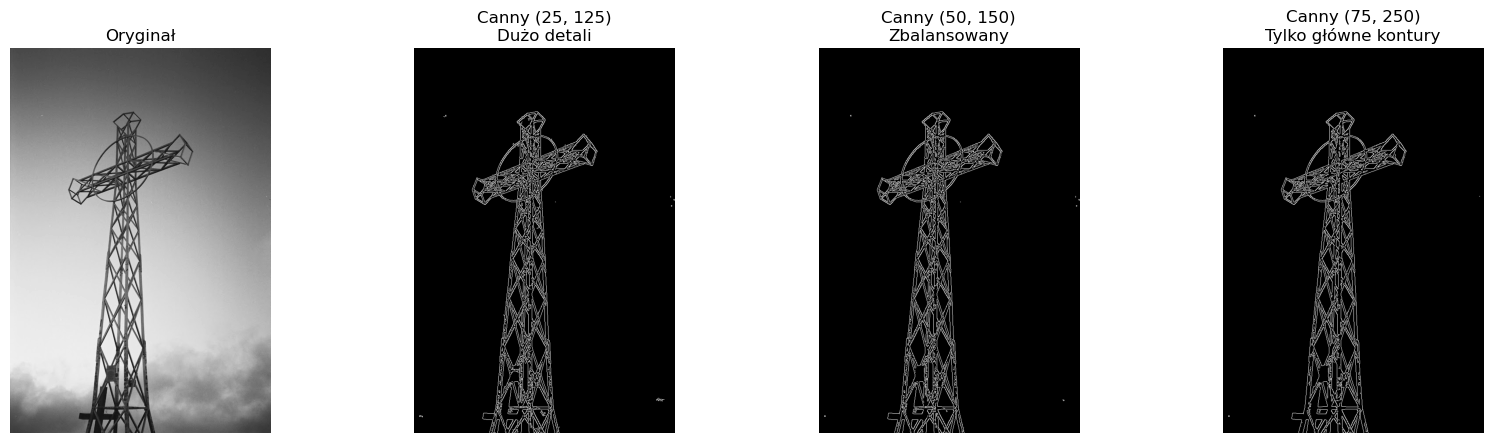

In [6]:
if base_img is not None:
    # Testujemy parametry opisane na wykładzie
    
    # 1. Dużo szczegółów, ale więcej szumu (T1=25, T2=125)
    canny_detailed = cv2.Canny(base_img, 25, 125)
    
    # 2. Zbalansowana konfiguracja (T1=50, T2=150) - stosunek 1:3
    canny_balanced = cv2.Canny(base_img, 50, 150)

    # 3. Bardzo selektywny, wysoki próg górny (T1=75, T2=250)
    canny_selective = cv2.Canny(base_img, 75, 250)

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(base_img, cmap='gray'); ax[0].set_title('Oryginał')
    ax[1].imshow(canny_detailed, cmap='gray'); ax[1].set_title('Canny (25, 125)\nDużo detali')
    ax[2].imshow(canny_balanced, cmap='gray'); ax[2].set_title('Canny (50, 150)\nZbalansowany')
    ax[3].imshow(canny_selective, cmap='gray'); ax[3].set_title('Canny (75, 250)\nTylko główne kontury')
    for a in ax: a.axis('off')
    plt.show()